# BART backward-elimination feature selection (Run 14)

Estimator-specific selection: XGBoost-based RFE selects features XGBoost can exploit,
and run 12 showed that set hurt BART. This notebook runs `BartBackwardElimination` —
importances re-measured each iteration from BART's own `variable_inclusion`, six
seed-replicate fits in parallel per iteration (12 of 14 cores) to tame PGBART sampler
noise. Progress streams live to `/tmp/bart_rfe_progress.log` (nbconvert buffers cell
stdout until completion, so the sidecar file is the only live view).

**Selection discipline:** every decision below uses the 2022-2023 validation slice; the
2024+2025 hold-out is read exactly ONCE, in the final cell, for the selected set.
Selection is by validation-curve PEAK, not smallest-within-tolerance (see the run-13
experiment-log entry for why the tolerance rule over-shrinks on flat curves).

In [1]:
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_bart as pmb
import os, sys, time, threading
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
from data_science_utilities.models.bart.feature_selection.backward_elimination import (
    BartBackwardElimination,
)

RANDOM_SEED = 32
TARGET = 'target_win'
BART_NAN_SENTINEL = -100.0

# Selection metric: 'brier' (proper scoring rule, default) | 'roc_auc' | 'log_loss'.
# _SCORER maps (y, preds) -> score; _HIGHER_IS_BETTER drives the 1-SE direction
# (roc_auc higher-is-better; brier / log_loss lower-is-better).
SELECTION_METRIC = 'brier'
_SCORER = {'brier': brier_score_loss, 'roc_auc': roc_auc_score, 'log_loss': log_loss}[SELECTION_METRIC]
_HIGHER_IS_BETTER = SELECTION_METRIC == 'roc_auc'

# Run C: BART on the rank-only Brier-selected XGBoost trace (rfe_features_kfolds_brier.csv).
# Start pool 91 (the produced row nearest the run-14 ~3x-peak lineage). Switch the source
# CSV + START_POOL_SIZE for the full-set variant (Run D).
START_POOL_SIZE = 91

# Per-fit / per-iteration progress to a sidecar file: headless nbconvert buffers a
# cell's stdout until the cell finishes, so this is the only way to watch live.
_LOG_PATH = '/tmp/bart_rfe_progress.log'
_log_lock = threading.Lock()


def log_progress(message):
    line = f"{time.strftime('%H:%M:%S')} {message}\n"
    with _log_lock:
        with open(_LOG_PATH, 'a') as handle:
            handle.write(line)


START_FEATURES = list(pd.read_csv(
    '../../../../../data/predict_games/model_features_in/rfe_features_kfolds_brier.csv',
    index_col=0,
).loc[START_POOL_SIZE].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

train_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] < 2022]
valid_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2022) & (MODEL_INPUTS_DF['season'] < 2024)
]
y_train = train_df[TARGET].to_numpy(dtype=int)
y_valid = valid_df[TARGET].to_numpy(dtype=int)
log_progress(f'START run: {len(START_FEATURES)} starting features')
print(len(START_FEATURES), 'starting features')

91 starting features


In [2]:
def bart_fit(features, seed):
    """One BART fit: train on <2022, score the 2022-2023 validation slice with the
    configured SELECTION_METRIC, return the chain-averaged variable_inclusion. 2 chains
    / 2 cores per fit so six replicate fits run in parallel (12 of 14 cores, 2 left for
    the system).

    Selection-grade sampling: draws cut to 500 (full tune kept for PGBART mixing) --
    selection only needs the importance ranking and a validation score, both of which
    are posterior means that converge fast, and 6-replicate averaging absorbs the rest.
    The final hold-out fit keeps full 1000-draw / 4-chain sampling."""
    t0 = time.perf_counter()
    X_train = train_df[features].fillna(BART_NAN_SENTINEL).to_numpy(dtype=float)
    X_valid = valid_df[features].fillna(BART_NAN_SENTINEL).to_numpy(dtype=float)
    assert not np.isnan(X_train).any() and not np.isnan(X_valid).any()

    with pm.Model() as model:
        X_data = pm.Data('X', X_train)
        mu = pmb.BART('mu', X_data, y_train, m=50)
        p = pm.Deterministic('p', pm.math.invprobit(mu))
        pm.Bernoulli('y', p=p, observed=y_train, shape=mu.shape)
        idata = pm.sample(draws=500, tune=1000, chains=2, cores=2,
                          random_seed=seed, progressbar=False)
        pm.set_data({'X': X_valid})
        ppc = pm.sample_posterior_predictive(
            idata, var_names=['p'], random_seed=seed, progressbar=False)

    valid_preds = ppc.posterior_predictive['p'].mean(dim=['chain', 'draw']).to_numpy()
    inclusion = pd.Series(
        idata.sample_stats['variable_inclusion']
        .mean(dim=['chain', 'draw']).to_numpy(),
        index=features,
    )
    score = _SCORER(y_valid, valid_preds)
    log_progress(f'  fit done: {len(features)} feat, seed {seed}, '
                 f'{time.perf_counter() - t0:.0f}s, valid {SELECTION_METRIC} {score:.4f}')
    return {'validation_score': score, 'variable_inclusion': inclusion}

In [3]:
def on_iter(row):
    log_progress(f'=== ITER complete: {row["num_features"]} features, '
                 f'mean validation {row["validation_score"]:.4f} ===')


rfe = BartBackwardElimination(bart_fit, drop_rate=0.2, min_features=10,
                              replicates=6, max_workers=6, base_seed=RANDOM_SEED,
                              on_iteration=on_iter)
history = rfe.run(START_FEATURES)
log_progress('DONE selection loop')
history[['num_features', 'validation_score', 'replicate_scores']]

ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: constant_folding


ERROR (pytensor.graph.rewriting.basic): node: Sqrt([2.])


ERROR (pytensor.graph.rewriting.basic): TRACEBACK:


ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniforge/base/envs/nfl-predictions/lib/python3.11/site-packages/pytensor/graph/rewriting/basic.py", line 1922, in process_node
    replacements = node_rewriter.transform(fgraph, node)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Caskroom/miniforge/base/envs/nfl-predictions/lib/python3.11/site-packages/pytensor/graph/rewriting/basic.py", line 1086, in transform
    return self.fn(fgraph, node)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Caskroom/miniforge/base/envs/nfl-predictions/lib/python3.11/site-packages/pytensor/tensor/rewriting/basic.py", line 1160, in constant_folding
    return unconditional_constant_folding.transform(fgraph, node)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Caskroom/miniforge/base/envs/nfl-predictions/lib/python3.11/site-packages/pytensor/graph/rewriting/basic.py", li

ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: constant_folding


...

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Sampling: [mu]


,num_features,validation_score,replicate_scores
0,91,0.230082,"[0.22983765819121718, 0.22976026678083938, 0.2..."
1,73,0.230033,"[0.23046951702382143, 0.2298354888162124, 0.22..."
2,59,0.229796,"[0.22949204848852778, 0.22961458097215, 0.2299..."
3,48,0.229917,"[0.22965821756165875, 0.22961430441919875, 0.2..."
4,39,0.229833,"[0.2295225434496853, 0.2303166404728166, 0.229..."
5,32,0.230046,"[0.23010602030678118, 0.23003291369696519, 0.2..."
6,26,0.229668,"[0.2296431858643695, 0.2293303654472747, 0.229..."
7,21,0.230453,"[0.23034348221578768, 0.23047091969856434, 0.2..."
8,17,0.231047,"[0.2312108753522421, 0.23120746462315234, 0.23..."
9,14,0.230824,"[0.2310463543815683, 0.2311381900711539, 0.231..."


1-SE selected 26 features, best brier 0.2297


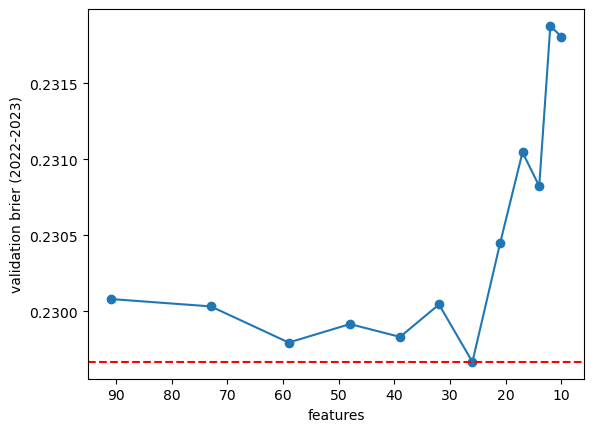

In [4]:
plt.plot(history['num_features'], history['validation_score'], marker='o')
plt.gca().invert_xaxis()
_best_score = history['validation_score'].max() if _HIGHER_IS_BETTER else history['validation_score'].min()
plt.axhline(_best_score, color='r', linestyle='--')
plt.xlabel('features')
plt.ylabel(f'validation {SELECTION_METRIC} (2022-2023)')
best_features = rfe.get_best_features_1se(higher_is_better=_HIGHER_IS_BETTER)
print('1-SE selected', len(best_features), 'features,',
      f"best {SELECTION_METRIC} {_best_score:.4f}")

In [5]:
pd.DataFrame({'feature': best_features}).to_csv(
    '../../../../../data/predict_games/model_features_in/bart_rfe_features_brier.csv',
    index=False,
)
sorted(best_features)

['def_opp_fumble_lost_rate_garbage_trailing_cumulative_average_rank',
 'def_opp_run_left_tackle_yards_per_attempt_garbage_leading_cumulative_average_rank',
 'def_opp_run_right_end_yards_per_attempt_garbage_trailing_cumulative_average_rank',
 'def_opp_rushing_yards_cumulative_average_rank',
 'def_target_run_right_end_explosive_rate_garbage_trailing_cumulative_average_rank',
 'def_target_rushing_yards_cumulative_average_rank',
 'def_target_sack_rate_garbage_leading_cumulative_average_rank',
 'is_home_target',
 'off_opp_early_down_success_rate_competitive_cumulative_average_rank',
 'off_opp_epa_per_play_competitive_cumulative_average_rank',
 'off_opp_pass_success_rate_competitive_cumulative_average_rank',
 'off_opp_passing_epa_cumulative_average_rank',
 'off_opp_sack_yards_cumulative_average_rank',
 'off_opp_success_rate_competitive_cumulative_average_rank',
 'off_target_early_down_success_rate_competitive_cumulative_average_rank',
 'off_target_epa_per_play_competitive_cumulative_average_

### Selected-set composition (reproducible from the two committed CSVs)

The README's run-14 figures are derivable from `bart_rfe_features.csv` (this run) and the
XGBoost RFE trace, no BART re-run needed:

```python
import pandas as pd, re
bart32 = set(pd.read_csv('../../../../../data/predict_games/model_features_in/bart_rfe_features.csv')['feature'])
xgb32 = set(pd.read_csv('../../../../../data/predict_games/model_features_in/rfe_features_kfolds.csv',
                        index_col=0).loc[32].dropna())
len(bart32 & xgb32)  # -> 17 (of 32): same count, different composition
pbp = lambda s: sum(bool(re.search(r'_yards_per_attempt_|_explosive_rate_|sack_rate|qb_hit_rate|'
                                    r'stuff_rate|fumble_lost_rate|scramble_rate|shotgun_rate|'
                                    r'no_huddle_rate|cpoe|yac_over_expected|pen_|seconds_per_play', f)) for f in s)
pbp(bart32)  # -> 9 pbp (6 directional, 3 Phase 3); the other 23 are box-score/Phase-1 ranks
```

Note: the `rfe_features_kfolds.csv` `.loc[32]` row is overwritten by whichever RFE run
ran last, so reproduce the overlap against the run-13 (Phase 3 pool) trace specifically.

In [6]:
# THE single hold-out read: final 4-chain fit on the selected set, evaluated
# exactly as bart.ipynb does.
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] >= 2024].copy()
y_holdout = holdout_df[TARGET].to_numpy(dtype=int)
X_train_full = train_df[best_features].fillna(BART_NAN_SENTINEL).to_numpy(dtype=float)
X_holdout = holdout_df[best_features].fillna(BART_NAN_SENTINEL).to_numpy(dtype=float)
assert not np.isnan(X_train_full).any() and not np.isnan(X_holdout).any()

with pm.Model() as final_model:
    X_data = pm.Data('X', X_train_full)
    mu = pmb.BART('mu', X_data, y_train, m=50)
    p = pm.Deterministic('p', pm.math.invprobit(mu))
    pm.Bernoulli('y', p=p, observed=y_train, shape=mu.shape)
    idata_final = pm.sample(draws=1000, tune=1000, chains=4, cores=4,
                            random_seed=RANDOM_SEED, progressbar=False)
    pm.set_data({'X': X_holdout})
    ppc_final = pm.sample_posterior_predictive(
        idata_final, var_names=['p'], random_seed=RANDOM_SEED, progressbar=False)

post_p = ppc_final.posterior_predictive['p']
holdout_preds = post_p.mean(dim=['chain', 'draw']).to_numpy()
holdout_std = post_p.std(dim=['chain', 'draw']).to_numpy()
print(f'final fit on {len(best_features)} features; holdout {X_holdout.shape}')
print(f'2024+2025 hold-out ROC-AUC:  {roc_auc_score(y_holdout, holdout_preds):.4f}')
print(f'2024+2025 hold-out accuracy: {((holdout_preds > 0.5).astype(int) == y_holdout).mean():.4f}')
print(f'Brier score: {brier_score_loss(y_holdout, holdout_preds):.4f}')
print(f'Log loss:    {log_loss(y_holdout, holdout_preds):.4f}')
width_quartile = pd.qcut(pd.Series(holdout_std), 4,
                         labels=['narrowest', 'q2', 'q3', 'widest'])
stratified = pd.DataFrame({'y': y_holdout, 'p': holdout_preds}).groupby(
    width_quartile, observed=True
).apply(lambda x: brier_score_loss(x['y'], x['p']), include_groups=False)
print('Brier by posterior-width quartile:')
print(stratified.round(4).to_string())

Multiprocess sampling (4 chains in 4 jobs)


PGBART: [mu]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 167 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Sampling: [mu]


final fit on 26 features; holdout (1088, 26)
2024+2025 hold-out ROC-AUC:  0.7030
2024+2025 hold-out accuracy: 0.6461
Brier score: 0.2192
Log loss:    0.6279
Brier by posterior-width quartile:
narrowest    0.1633
q2           0.2247
q3           0.2427
widest       0.2462
